# BGL Log Anomaly Detection: Isolation Forest Pipeline

### Pipeline 1 — Isolation Forest
**Stage 1 — Isolation Forest**
- Trained exclusively on normal logs (50 % of all normal logs)
- Learns to isolate anomalies by randomly partitioning the feature space
- Flags any test log that is isolated quickly (low average path length) as anomalous

**Key Properties**
1. **No distance metric** — anomaly score based on tree path length, not hypersphere distance
2. **Efficient on high-dimensional data** — works directly on sentence embeddings without dimensionality reduction
3. **No threshold calibration needed** — `contamination` parameter governs the decision boundary
4. **Validation-set score calibration** — threshold derived from held-out normal logs for precision control
5. **Precision-recall curve threshold selection** — F-beta (β=0.5) maximisation to explicitly weight precision over recall

**Evaluation**
- Traditional binary metrics: Accuracy, Precision, Recall, F1-Score

## Dataset
- Source          : BGL 2k structured log dataset
- Label convention: `'-'` = Normal, any other label = Anomalous
- IF training     : 50 % of all normal logs
- Validation set  : 200 held-out normal logs (threshold calibration only — never seen during training)
- Test set        : drawn from remaining held-out normal logs and anomalous logs


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
#
# Install all third-party dependencies required by this notebook.
# Run this cell once before executing Cell 2.
# PyTorch is NOT required — Isolation Forest runs on scikit-learn.
# =============================================================================

import subprocess
import sys


def install_packages(packages):
    """
    Install a list of pip packages programmatically.

    Args:
        packages: List of pip-installable package specifiers.
    """
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: installation may have failed for {pkg}")
            print(f"  stderr: {result.stderr[:200]}")
        else:
            print(f"  OK")


REQUIRED_PACKAGES = [
    # Data science core
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    # Embedding model
    "sentence-transformers",
]

install_packages(REQUIRED_PACKAGES)
print("\nAll packages installed successfully.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: sentence-transformers
  OK

All packages installed successfully.


C:\Users\Abhishek Mulay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Embedding model   : all-MiniLM-L6-v2
  IF n_estimators   : 200
  IF max_samples    : auto
  IF max_features   : 1.0
  IF contamination  : auto
  IF train ratio    : 0.5
  Val normal count  : 200
  F-beta            : 0.5
  Test set size     : 825  (800 normal + 25 anomalous)
Loading BGL structured log dataset ...
  Structured log rows : 2000
  Template rows       : 120
  Label distribution  :
-           1857
KERNDTLB      60
KERNSTOR      30
APPSEV        17
KERNMNTF      11
KERNTERM       7
KERNREC        5
APPRES         4
APPREAD        3
APPTO          2
KERNRTSP       2
APPCHILD       1
APPOUT         1
  Normal logs         : 1857
  Anomalous logs      : 143
  Sample log text     : [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected
Splitting dataset ...
  IF training logs          : 928 (normal only)
  Held-out normal logs      : 929
  Validation normal logs    : 200  (threshold calibration)
  Test normal logs         

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2683.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384
Encoding IF training logs ...


Batches: 100%|██████████| 15/15 [00:08<00:00,  1.73it/s]


  IF training embeddings shape : (928, 384)
Encoding validation logs ...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.60it/s]


  Validation embeddings shape  : (200, 384)
Encoding test logs ...


Batches: 100%|██████████| 12/12 [00:06<00:00,  1.72it/s]


  Test embeddings shape        : (754, 384)
Training Isolation Forest on normal logs ...
  Isolation Forest training complete.
    Trees fitted      : 200
    Features used     : 384
Computing validation-set anomaly scores for threshold calibration ...
  Validation score stats (normal logs only):
    Min    : 0.3556
    Median : 0.4315
    Max    : 0.5595

  Threshold selection via F-beta (beta=0.5) on validation PR curve:
    Best threshold : 0.5339
    At threshold   : Precision=1.000, Recall=1.000, F0.5=1.000

Scoring test logs with Isolation Forest ...
  IF flagged as Anomalous : 53
  IF flagged as Normal    : 701
Computing Pipeline 1 traditional binary classification metrics ...

  PIPELINE EVALUATION (Isolation Forest)
  Test set size      : 754
    Normal  (neg)    : 729
    Anomalous (pos)  : 25
--------------------------------------------------------------
  TP (caught anomalies) : 5
  TN (correct normals)  : 681
  FP (false alarms)     : 48
  FN (missed anomalies) : 20
------

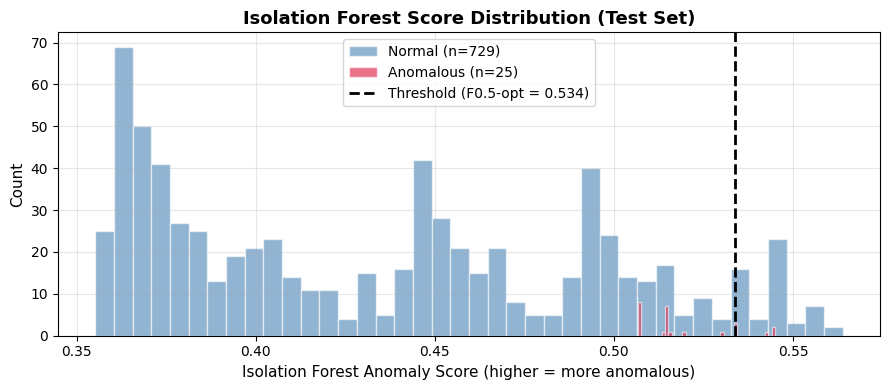

  Saved: if_score_distribution.png


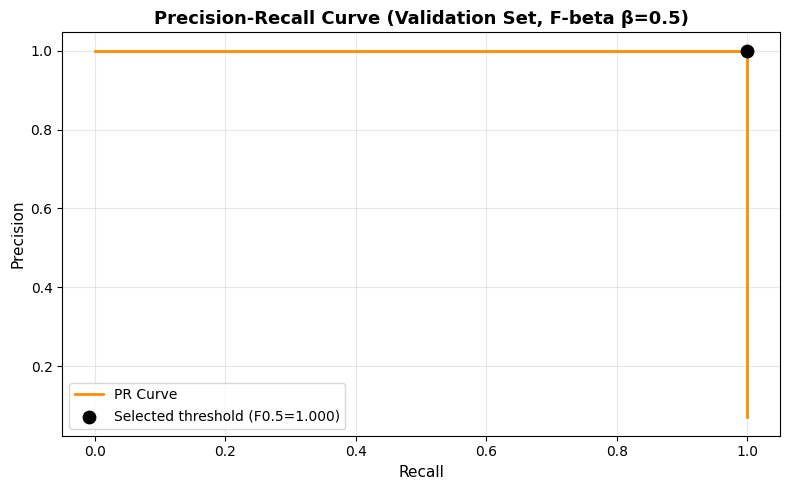

  Saved: if_pr_curve.png


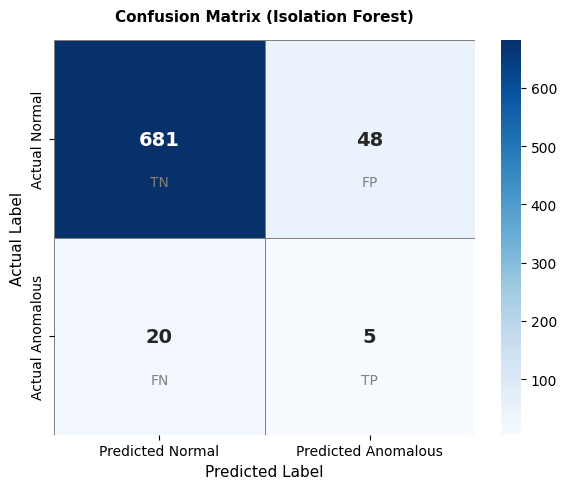

  Saved: p1_confusion_matrix.png


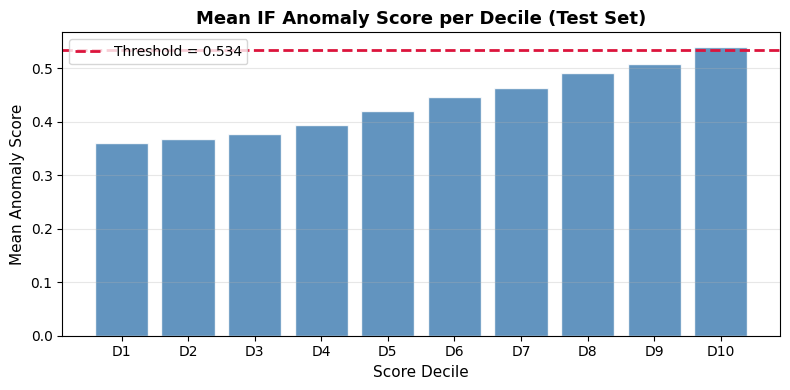

  Saved: if_score_deciles.png


In [2]:
# =============================================================================
# CELL 2 — MAIN PIPELINE  (Isolation Forest)
#
# Replaces Deep SVDD with scikit-learn IsolationForest while retaining:
#   - Identical data loading and preprocessing
#   - Identical 50/50 normal train split
#   - Identical 200-log held-out validation set for threshold calibration
#   - Identical test set composition (800 normal + 25 anomalous)
#   - Identical evaluation metrics and visualisations
#
# Sections:
#   1.  Imports and global configuration
#   2.  Data loading and preprocessing
#   3.  Train / validation / test split
#   4.  Isolation Forest training
#   5.  Validation-set threshold calibration
#   6.  Isolation Forest anomaly detection on the test set
#   7.  Evaluation: traditional classification metrics
#   8.  Visualisations
# =============================================================================


# ---------------------------------------------------------------------------
# Section 1: Imports and global configuration
# ---------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

# Reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Pipeline configuration
# ---------------------------------------------------------------------------

# File paths
STRUCTURED_LOG_PATH = "../BGL/BGL_2k.log_structured.csv"
TEMPLATES_PATH      = "../BGL/BGL_2k.log_templates.csv"

# Embedding model (384-dimensional output)
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"

# Isolation Forest hyper-parameters
IF_N_ESTIMATORS   = 200    # Number of isolation trees
IF_MAX_SAMPLES    = "auto" # Samples per tree ("auto" = min(256, n_train))
IF_MAX_FEATURES   = 1.0   # Fraction of features per split
IF_CONTAMINATION  = "auto" # Let threshold calibration handle the cut-off

# Training split (unchanged from Deep SVDD pipeline)
IF_TRAIN_RATIO = 0.50  # Fraction of normal logs used for IF training

# Validation set size for threshold calibration (unchanged)
VAL_NORMAL_COUNT = 200  # Held-out normal logs used only for threshold calibration

# F-beta weight for PR-curve threshold selection (unchanged)
FBETA = 0.5  # beta=0.5 weights precision 2x over recall

# Test set composition (unchanged)
TEST_SET_SIZE        = 825
TEST_NORMAL_COUNT    = 800
TEST_ANOMALOUS_COUNT = 25

print(f"  Embedding model   : {EMBED_MODEL_NAME}")
print(f"  IF n_estimators   : {IF_N_ESTIMATORS}")
print(f"  IF max_samples    : {IF_MAX_SAMPLES}")
print(f"  IF max_features   : {IF_MAX_FEATURES}")
print(f"  IF contamination  : {IF_CONTAMINATION}")
print(f"  IF train ratio    : {IF_TRAIN_RATIO}")
print(f"  Val normal count  : {VAL_NORMAL_COUNT}")
print(f"  F-beta            : {FBETA}")
print(f"  Test set size     : {TEST_SET_SIZE}  "
      f"({TEST_NORMAL_COUNT} normal + {TEST_ANOMALOUS_COUNT} anomalous)")


# ---------------------------------------------------------------------------
# Section 2: Data loading and preprocessing
# ---------------------------------------------------------------------------


def build_log_text(row):
    """
    Construct a structured text representation of a single log row.

    Combines the component name, severity level, raw log content, and the
    parsed event template into one string. This enriched representation
    improves embedding quality by exposing both the concrete content and
    the abstract pattern to the sentence transformer.

    Args:
        row: A pandas Series or dict-like object with keys Component,
             Level, Content, and EventTemplate.

    Returns:
        A formatted string of the form:
        "[COMPONENT] [LEVEL] <content> | Template: <template>"
    """
    component = str(row.get("Component", "")).strip()
    level     = str(row.get("Level", "")).strip()
    content   = str(row.get("Content", "")).strip()
    template  = str(row.get("EventTemplate", "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


print("Loading BGL structured log dataset ...")
df_logs      = pd.read_csv(STRUCTURED_LOG_PATH)
df_templates = pd.read_csv(TEMPLATES_PATH)

print(f"  Structured log rows : {len(df_logs)}")
print(f"  Template rows       : {len(df_templates)}")
print(f"  Label distribution  :")
print(df_logs["Label"].value_counts().to_string(header=False))

# Binary labels: '-' is Normal; anything else is Anomalous
df_logs["is_normal"]    = df_logs["Label"] == "-"
df_logs["binary_label"] = df_logs["is_normal"].apply(lambda x: 0 if x else 1)

# Merge templates to enrich log text with the parsed event pattern
df_merged = df_logs.merge(
    df_templates, on="EventId", how="left", suffixes=("", "_template")
)
df_merged["log_text"] = df_merged.apply(build_log_text, axis=1)

n_normal    = df_merged["is_normal"].sum()
n_anomalous = (~df_merged["is_normal"]).sum()
print(f"  Normal logs         : {n_normal}")
print(f"  Anomalous logs      : {n_anomalous}")
print(f"  Sample log text     : {df_merged['log_text'].iloc[0]}")


# ---------------------------------------------------------------------------
# Section 3: Train / validation / test split
#
# Split strategy (identical to Deep SVDD pipeline):
#   - IF training set   : 50 % of all normal logs (learns normal behaviour)
#   - Validation set    : VAL_NORMAL_COUNT held-out normal logs
#                         (threshold calibration only — never seen during training)
#   - Test set          : remaining held-out normal logs + anomalous logs
# ---------------------------------------------------------------------------

print("Splitting dataset ...")

all_normal    = df_merged[df_merged["is_normal"]].copy()
all_anomalous = df_merged[~df_merged["is_normal"]].copy()

# Shuffle normal logs before splitting for reproducibility
all_normal = all_normal.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# IF training set: first 50 % of normal logs
n_if_train   = int(len(all_normal) * IF_TRAIN_RATIO)
if_train_df  = all_normal.iloc[:n_if_train].reset_index(drop=True)

# Held-out normal logs: remaining 50 %
held_out_normal_df = all_normal.iloc[n_if_train:].reset_index(drop=True)

# Validation split: first VAL_NORMAL_COUNT from held-out normals
val_normal_df = held_out_normal_df.iloc[:VAL_NORMAL_COUNT].reset_index(drop=True)

# Test normals: everything after the validation slice
post_val_normal_df = held_out_normal_df.iloc[VAL_NORMAL_COUNT:].reset_index(drop=True)

# Test set: sample TEST_NORMAL_COUNT from post-validation held-out normals
#           and TEST_ANOMALOUS_COUNT from all anomalous logs
test_normal_sample = post_val_normal_df.sample(
    n=min(TEST_NORMAL_COUNT, len(post_val_normal_df)), random_state=RANDOM_SEED
).reset_index(drop=True)
test_anomalous_sample = all_anomalous.sample(
    n=min(TEST_ANOMALOUS_COUNT, len(all_anomalous)), random_state=RANDOM_SEED
).reset_index(drop=True)

df_test = pd.concat(
    [test_normal_sample, test_anomalous_sample], ignore_index=True
)
df_test = df_test.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"  IF training logs          : {len(if_train_df)} (normal only)")
print(f"  Held-out normal logs      : {len(held_out_normal_df)}")
print(f"  Validation normal logs    : {len(val_normal_df)}  (threshold calibration)")
print(f"  Test normal logs          : {len(test_normal_sample)}")
print(f"  Test anomalous logs       : {len(test_anomalous_sample)}")
print(f"  Total test logs           : {len(df_test)}")
print(f"  Test set normal ratio     : "
      f"{len(test_normal_sample) / len(df_test) * 100:.1f} %")
print(f"  Test set anomalous ratio  : "
      f"{len(test_anomalous_sample) / len(df_test) * 100:.1f} %")


# ---------------------------------------------------------------------------
# Section 4: Embedding model
# ---------------------------------------------------------------------------

print(f"Loading embedding model '{EMBED_MODEL_NAME}' ...")
embedder         = SentenceTransformer(EMBED_MODEL_NAME)
actual_embed_dim = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {actual_embed_dim}")

print("Encoding IF training logs ...")
if_train_texts      = if_train_df["log_text"].tolist()
if_train_embeddings = embedder.encode(
    if_train_texts, batch_size=64, show_progress_bar=True
)
print(f"  IF training embeddings shape : {if_train_embeddings.shape}")

print("Encoding validation logs ...")
val_texts      = val_normal_df["log_text"].tolist()
val_embeddings = embedder.encode(
    val_texts, batch_size=64, show_progress_bar=True
)
print(f"  Validation embeddings shape  : {val_embeddings.shape}")

print("Encoding test logs ...")
test_texts      = df_test["log_text"].tolist()
test_embeddings = embedder.encode(
    test_texts, batch_size=64, show_progress_bar=True
)
print(f"  Test embeddings shape        : {test_embeddings.shape}")


# ---------------------------------------------------------------------------
# Section 5: Isolation Forest training
#
# IsolationForest is trained on normal-only embeddings.
# It builds an ensemble of random isolation trees; anomalies are points
# that are isolated near the root of a tree (short average path length).
#
# score_samples() returns the negative anomaly score:
#   - Higher (less negative) score  →  more normal
#   - Lower  (more negative) score  →  more anomalous
# We negate scores so that higher values indicate higher anomaly likelihood,
# consistent with the threshold convention used by the Deep SVDD pipeline.
# ---------------------------------------------------------------------------

print("Training Isolation Forest on normal logs ...")
iso_forest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    max_features=IF_MAX_FEATURES,
    contamination=IF_CONTAMINATION,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
iso_forest.fit(if_train_embeddings)
print("  Isolation Forest training complete.")
print(f"    Trees fitted      : {iso_forest.n_estimators}")
print(f"    Features used     : {if_train_embeddings.shape[1]}")


# ---------------------------------------------------------------------------
# Section 6: Validation-set threshold calibration
#
# Mirrors the Deep SVDD pipeline exactly:
#   - Score validation normals, negate so high = anomalous
#   - Build a pseudo-labelled PR curve (top 7 % of val scores = pseudo-anomaly)
#   - Pick the threshold that maximises F-beta (beta=0.5) on that curve
# ---------------------------------------------------------------------------

print("Computing validation-set anomaly scores for threshold calibration ...")
# score_samples returns negative anomaly score; negate → high = anomalous
val_scores = -iso_forest.score_samples(val_embeddings)

print(f"  Validation score stats (normal logs only):")
print(f"    Min    : {val_scores.min():.4f}")
print(f"    Median : {np.median(val_scores):.4f}")
print(f"    Max    : {val_scores.max():.4f}")

# Pseudo-label: top 7 % of validation scores treated as pseudo-anomalies
pseudo_anomaly_pctile = 93
pseudo_labels = (
    val_scores >= np.percentile(val_scores, pseudo_anomaly_pctile)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_scores
)

# F-beta: (1 + beta^2) * P * R / (beta^2 * P + R)
beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx      = int(np.argmax(fbeta_scores))
if_threshold  = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold : {if_threshold:.4f}")
print(f"    At threshold   : Precision={pr_precisions[best_idx]:.3f}, "
      f"Recall={pr_recalls[best_idx]:.3f}, "
      f"F{FBETA}={fbeta_scores[best_idx]:.3f}")


# ---------------------------------------------------------------------------
# Section 7: Isolation Forest anomaly detection on the test set
# ---------------------------------------------------------------------------

print("\nScoring test logs with Isolation Forest ...")
# Negate score_samples so high value = more anomalous
test_scores = -iso_forest.score_samples(test_embeddings)

# Binary IF predictions (1 = Anomalous, 0 = Normal)
if_pred   = (test_scores > if_threshold).astype(int)
if_true   = df_test["binary_label"].values  # ground truth

n_if_flagged = int(if_pred.sum())
n_if_normal  = int((if_pred == 0).sum())
print(f"  IF flagged as Anomalous : {n_if_flagged}")
print(f"  IF flagged as Normal    : {n_if_normal}")


# ---------------------------------------------------------------------------
# Section 8: Evaluation — traditional binary classification metrics
#
# Ground truth  : binary_label from the dataset (0 = Normal, 1 = Anomalous)
# Positive class: Anomalous (1)
# ---------------------------------------------------------------------------

print("Computing Pipeline 1 traditional binary classification metrics ...")

p1_y_true = if_true.tolist()
p1_y_pred = if_pred.tolist()

p1_accuracy  = accuracy_score(p1_y_true, p1_y_pred)
p1_precision = precision_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)
p1_recall    = recall_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)
p1_f1        = f1_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)

p1_cm = confusion_matrix(p1_y_true, p1_y_pred)
p1_tn, p1_fp, p1_fn, p1_tp = p1_cm.ravel()

print("\n" + "=" * 62)
print("  PIPELINE EVALUATION (Isolation Forest)")
print("=" * 62)
print(f"  Test set size      : {len(p1_y_true)}")
print(f"    Normal  (neg)    : {p1_y_true.count(0)}")
print(f"    Anomalous (pos)  : {p1_y_true.count(1)}")
print("-" * 62)
print(f"  TP (caught anomalies) : {p1_tp}")
print(f"  TN (correct normals)  : {p1_tn}")
print(f"  FP (false alarms)     : {p1_fp}")
print(f"  FN (missed anomalies) : {p1_fn}")
print("-" * 62)
print(f"  Accuracy              : {p1_accuracy:.4f}  ({p1_accuracy * 100:.2f} %)")
print(f"  Precision             : {p1_precision:.4f}")
print(f"  Recall                : {p1_recall:.4f}")
print(f"  F1-Score              : {p1_f1:.4f}")
print(f"  FPR                   : {p1_fp/(p1_fp + p1_tn):.4f}")
print(f"  FNR                   : {p1_fn/(p1_fn + p1_tp):.4f}")
print("=" * 62)


# ---------------------------------------------------------------------------
# Section 9: Visualisations
#
#   9a. Anomaly score distributions (Normal vs Anomalous test logs)
#        with the calibrated threshold line
#   9b. Precision-Recall curve with F-beta threshold marker
#   9c. Confusion matrix
#   9d. Feature importance proxy: mean anomaly score per score decile
# ---------------------------------------------------------------------------

print("Generating visualisations ...")

normal_mask    = if_true == 0
anomalous_mask = if_true == 1

# 9a. Anomaly score distributions
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    test_scores[normal_mask],
    bins=40,
    alpha=0.6,
    color="steelblue",
    label=f"Normal (n={normal_mask.sum()})",
    edgecolor="white",
)
ax.hist(
    test_scores[anomalous_mask],
    bins=40,
    alpha=0.6,
    color="crimson",
    label=f"Anomalous (n={anomalous_mask.sum()})",
    edgecolor="white",
)
ax.axvline(
    if_threshold,
    color="black",
    linestyle="--",
    lw=2,
    label=f"Threshold (F{FBETA}-opt = {if_threshold:.3f})",
)
ax.set_xlabel("Isolation Forest Anomaly Score (higher = more anomalous)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    "Isolation Forest Score Distribution (Test Set)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("if_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: if_score_distribution.png")

# 9b. Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
ax.scatter(
    [pr_recalls[best_idx]],
    [pr_precisions[best_idx]],
    color="black",
    zorder=5,
    s=80,
    label=f"Selected threshold (F{FBETA}={fbeta_scores[best_idx]:.3f})",
)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title(
    f"Precision-Recall Curve (Validation Set, F-beta β={FBETA})",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("if_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: if_pr_curve.png")

# 9c. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    p1_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax,
)
for (r, c), lbl in {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center",
        fontsize=10, color="grey",
    )
ax.set_title(
    "Confusion Matrix (Isolation Forest)",
    fontsize=11,
    fontweight="bold",
    pad=14,
)
ax.set_ylabel("Actual Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("p1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: p1_confusion_matrix.png")

# 9d. Anomaly score distribution by decile (score spread health check)
decile_bins = np.percentile(test_scores, np.arange(0, 110, 10))
decile_labels = [f"D{i}" for i in range(1, 11)]
decile_mean_scores = [
    test_scores[
        (test_scores >= decile_bins[i]) & (test_scores < decile_bins[i + 1])
    ].mean()
    for i in range(10)
]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    decile_labels,
    decile_mean_scores,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
ax.axhline(
    if_threshold,
    color="crimson",
    linestyle="--",
    lw=2,
    label=f"Threshold = {if_threshold:.3f}",
)
ax.set_xlabel("Score Decile", fontsize=11)
ax.set_ylabel("Mean Anomaly Score", fontsize=11)
ax.set_title(
    "Mean IF Anomaly Score per Decile (Test Set)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("if_score_deciles.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: if_score_deciles.png")
